# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [2]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [3]:
df.groupby('month_year')['count'].mean()

,count
month_year,
2011-01,54.645012
2011-02,73.641256
2011-03,86.849776
2011-04,111.026374
2011-05,174.809211
2011-06,196.877193
2011-07,203.614035
2011-08,182.666667
2011-09,174.622517


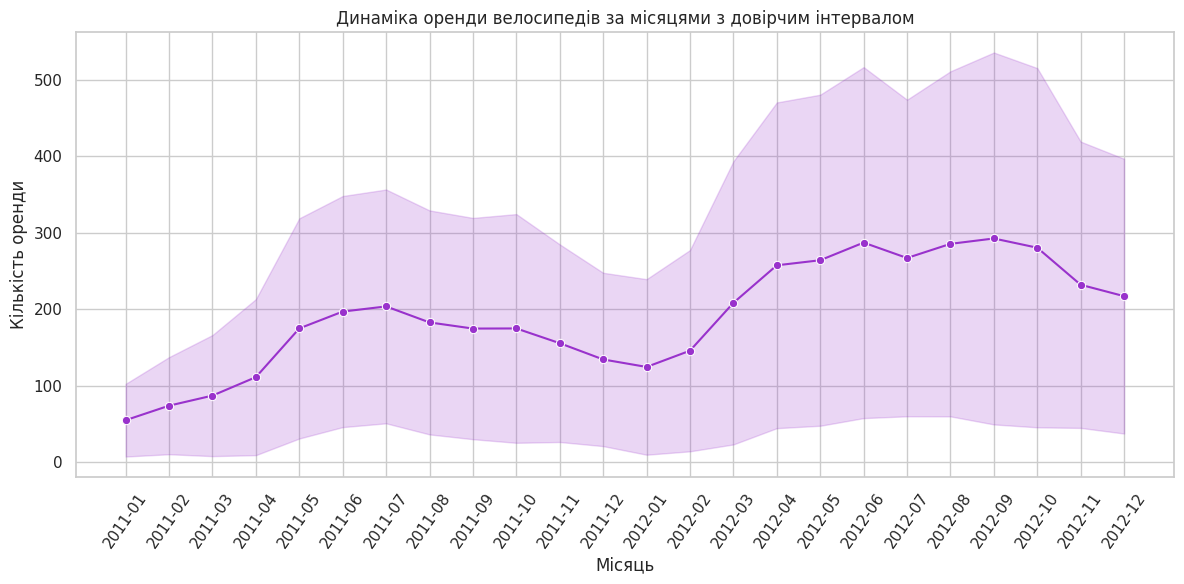

In [4]:
plt.figure(figsize=(12, 6))
sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o', color = 'darkorchid')
plt.title('Динаміка оренди велосипедів за місяцями з довірчим інтервалом')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=55)
plt.tight_layout();

В які місяці найбільша невизначеність в даних?

В 2011 році найбільша невизначеність в даних в червні, липні та жовтні місяці. В 2012 році найбільша невизначеність в даних червні, серпні, вересні, жовтні.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

<Axes: title={'center': 'Розподіл температури'}, xlabel='Температура', ylabel='Частота'>

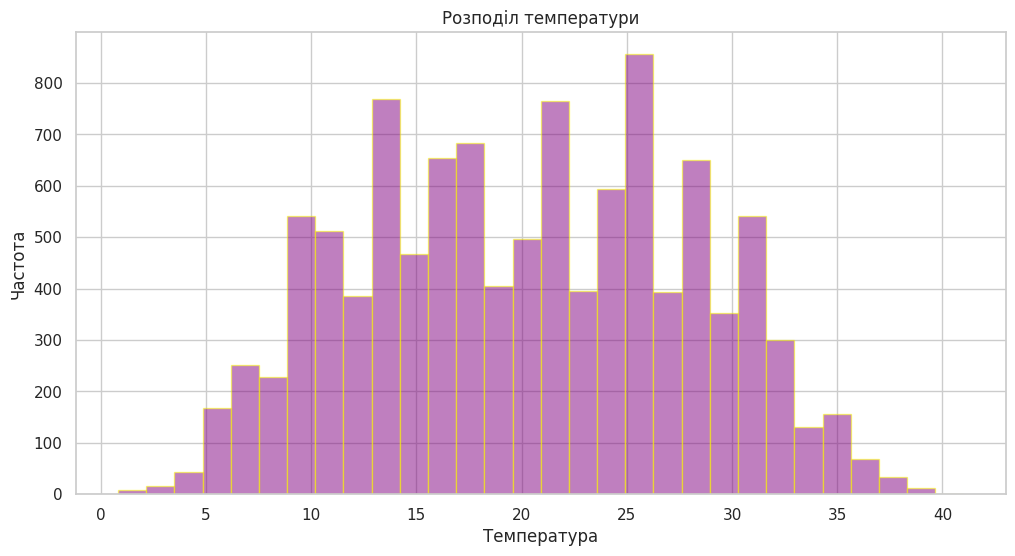

In [5]:
df['temp'].plot.hist(
    bins=30,
    figsize=(12, 6),
    alpha=0.5,
    color = 'purple',
    edgecolor='yellow',
    title='Розподіл температури',
    xlabel='Температура',
    ylabel='Частота',
)

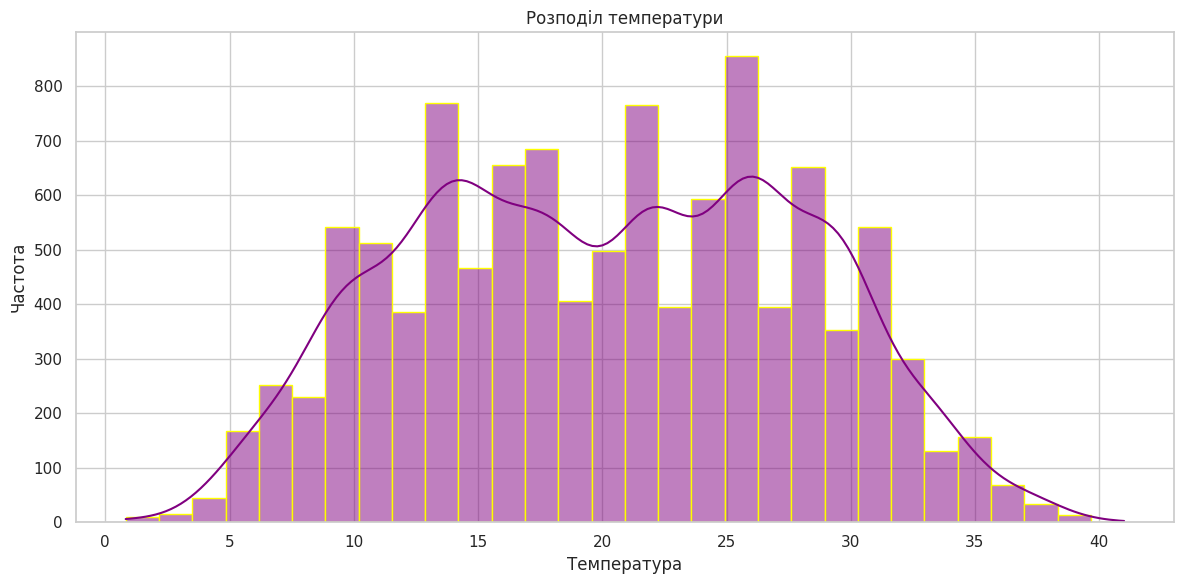

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(df, x='temp', bins=30, kde=True, color = 'purple', edgecolor='yellow', alpha=0.5)
plt.title('Розподіл температури')
plt.xlabel('Температура')
plt.ylabel('Частота')
plt.tight_layout();

1. Яка візуальна різниця між Pandas та Seaborn гістограмами?

Візуальна різниця між Pandas та Seaborn гістограмами мінімальна. Відмінність графіків полягає у наявності на гістограмі Seaborn лінійного графіку KDE, оцінки розподілу даних.

2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

На гістограмі Seaborn є додатковий лінійний графік KDE, оцінка розподілу даних.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [7]:
df.groupby('weather')['count'].sum()

,count
weather,
1,1476063
2,507160
3,102089
4,164


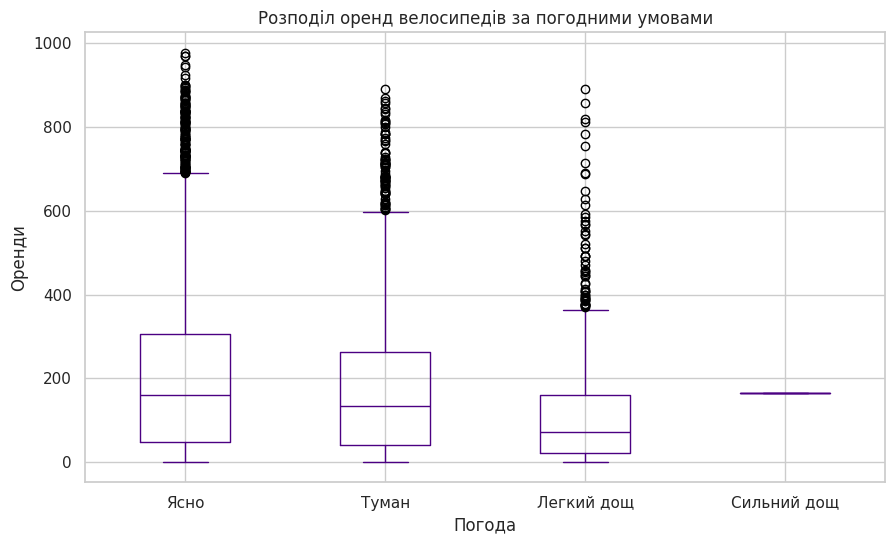

In [8]:
df.boxplot(
    column='count',
    by='weather',
    figsize=(10, 6),
    grid = True,
    color = 'indigo'
)
plt.title('Розподіл оренд велосипедів за погодними умовами')
plt.suptitle('')  # Видаляємо автоматичний заголовок
plt.xlabel('Погода')
plt.xticks(range(1, 5), ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.ylabel('Оренди')
plt.show()

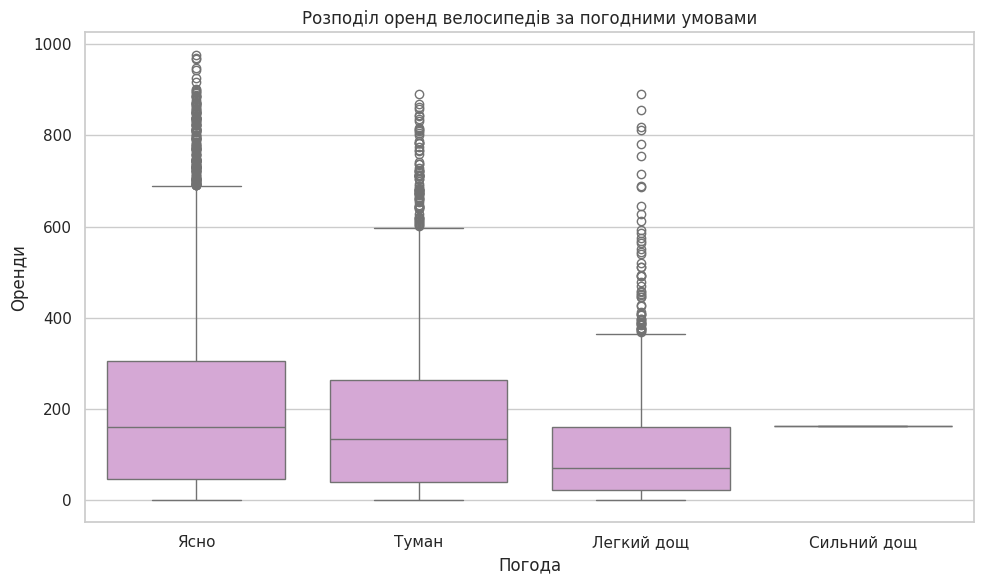

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(df, x='weather', y='count', color = 'plum')
plt.title('Розподіл оренд велосипедів за погодними умовами')
plt.xlabel('Погода')
plt.xticks(range(0, 4), ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.ylabel('Оренди')
plt.tight_layout();

Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

Seaborn бокс-плот має заливку всередині бокс-плотів, бокс-плоти візуально більшого розміру, розмір графіка Seaborn бокс-плотів - більший, хоча задані однакові значення.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [10]:
correlation = df[['count', 'casual', 'registered', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']].corr()
correlation

,count,casual,registered,weather,temp,atemp,humidity,windspeed
count,1.000000,0.690414,0.970948,-0.128655,0.394454,0.389784,-0.317371,0.101369
casual,0.690414,1.000000,0.497250,-0.135918,0.467097,0.462067,-0.348187,0.092276
registered,0.970948,0.497250,1.000000,-0.109340,0.318571,0.314635,-0.265458,0.091052
weather,-0.128655,-0.135918,-0.109340,1.000000,-0.055035,-0.055376,0.406244,0.007261
temp,0.394454,0.467097,0.318571,-0.055035,1.000000,0.984948,-0.064949,-0.017852
atemp,0.389784,0.462067,0.314635,-0.055376,0.984948,1.000000,-0.043536,-0.057473
humidity,-0.317371,-0.348187,-0.265458,0.406244,-0.064949,-0.043536,1.000000,-0.318607
windspeed,0.101369,0.092276,0.091052,0.007261,-0.017852,-0.057473,-0.318607,1.000000


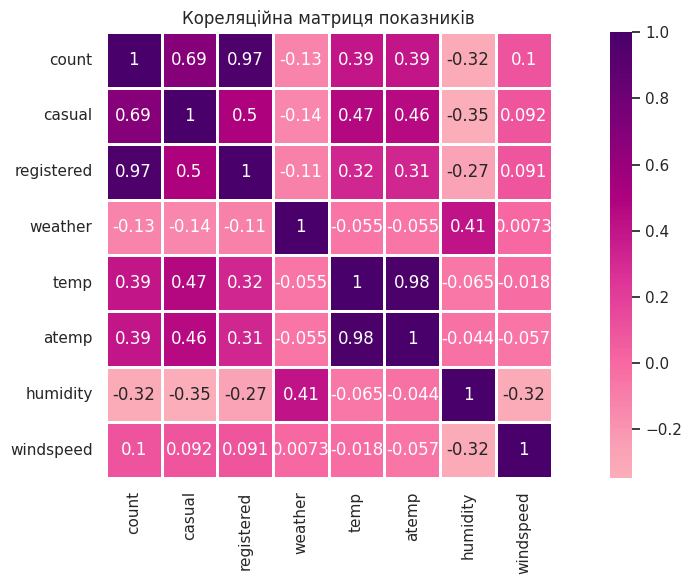

In [11]:
plt.figure(figsize=(12, 6))

sns.heatmap(correlation, annot=True, cmap='RdPu', center=0,
            square=True, linewidths=1
            )

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?

Із загальною кількістю оренди найсильніше корелюють: кількість оренд від зареєстрованих клієнтів та кількість оренд від незареєстрованих клієнтів.

2. Яка кореляція між temp та atemp? Чому?

Кореляція між temp та atemp має найвище значення для temp та atemp, тому, що temp - температура повітря, а atemp - як температура відчувається.

3. Які змінні мають негативну кореляцію?

Загальна кількість оренди, кількість оренд від зареєстрованих клієнтів та кількість оренд від незареєстрованих клієнтів мають негативну кореляцію з погоддою та вологістю. Погода та вологість також мають негативну кореляцію з atemp та temp. Аtemp та temp мають негативну кореляцію з погодою, вологістю та швидкістю вітру. Швидкість вітру має негативну кореляцію з atemp, temp та вологістю.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


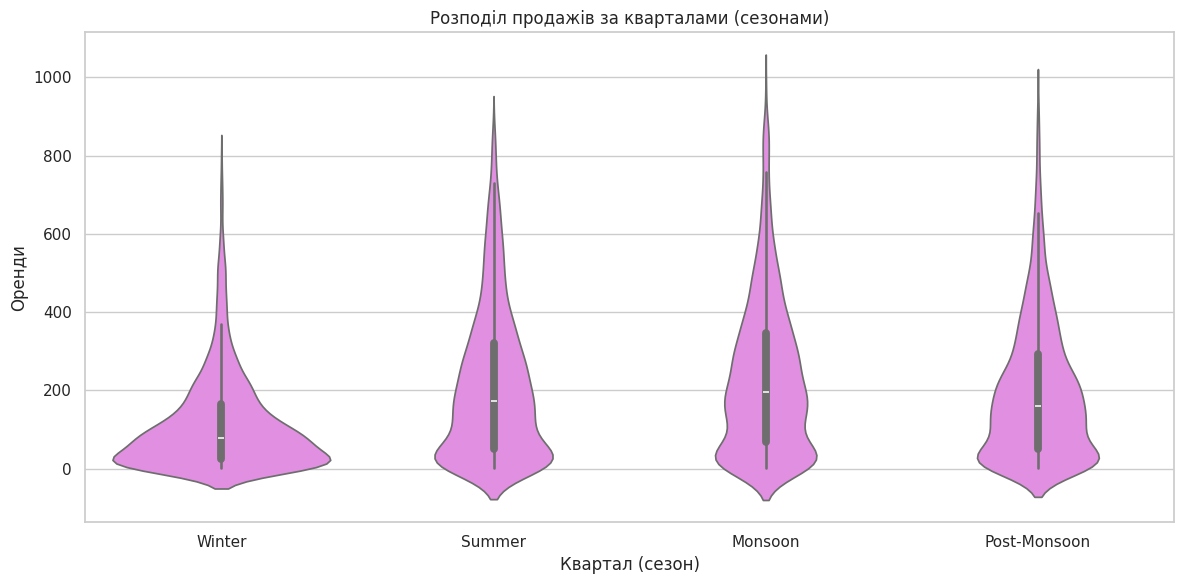

In [12]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season', y='count', color = 'violet')
plt.xticks(range(0, 4), ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
plt.title('Розподіл продажів за кварталами (сезонами)')
plt.xlabel('Квартал (сезон)')
plt.ylabel('Оренди')
plt.tight_layout()
plt.show()

1. Що показує "товщина" violin plot?

"Товщина" violin plot показує кількість оренд у цьому кварталі (сезоні).

2. В якому кварталі найбільша варіабельність оренди?

Варіабельність оренди більша у Summer та Monsoon.

3. Яка перевага violin plot над звичайним box plot?

Violin plot показує розподіл даних, де даних більше, а де менше, в той час як звичайний box plot показує короткий звіт (медіана, викиди, квартилі), по ньому складніше визначити розподіл даних.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

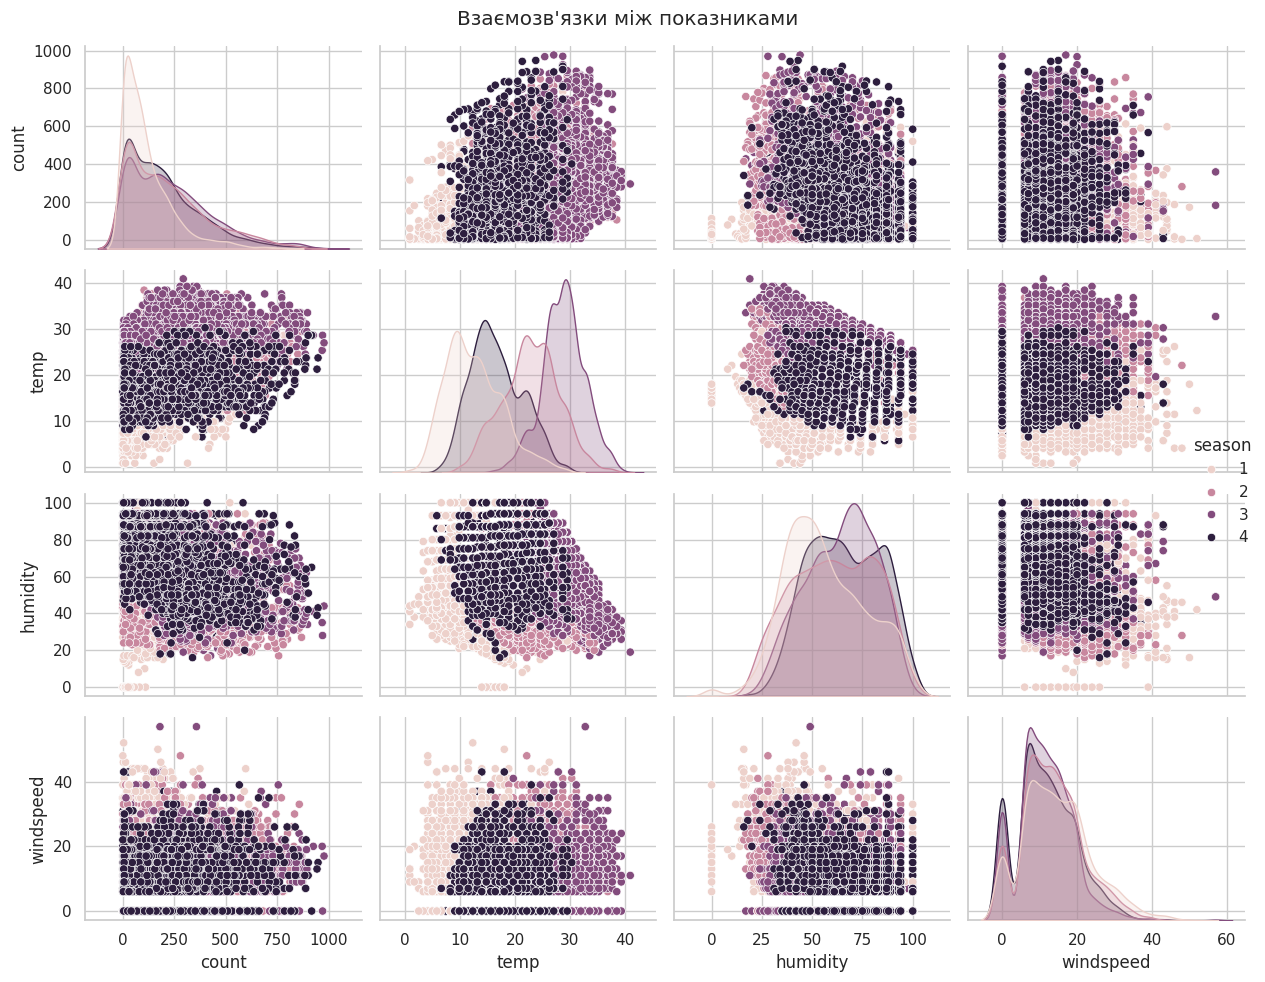

In [13]:
sample_df = df[['count', 'temp', 'humidity', 'windspeed', 'season']]
sns.pairplot(sample_df, height=2.5, aspect=1.2, hue="season")
plt.suptitle('Взаємозв\'язки між показниками')
plt.tight_layout()
plt.show()

1. Між якими змінними спостерігається найсильніший лінійний зв'язок?

Сильний лінійний зв'язок спостерігається між температурою та загальною кількістю оренд, між вологістю та загальною кількістю оренд.

2. Яка характеристика найбільше відрізняється між кварталами?

Між кварталами найбільше відрізняється температура.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

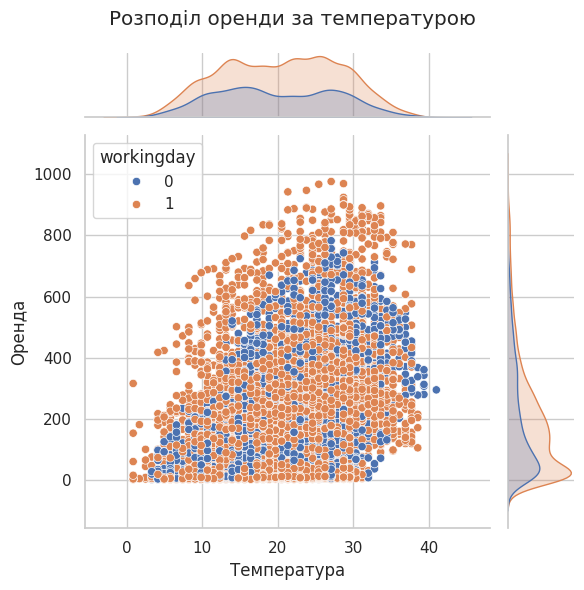

In [14]:
sns.jointplot(data=df, x="temp", y="count", hue="workingday")
plt.suptitle('Розподіл оренди за температурою')
plt.xlabel('Температура')
plt.ylabel('Оренда')
plt.tight_layout()
plt.show()

1. Що показують графіки по краях?

Графіки по краях показують: як часто зустрічається значення температури (вісь Ох, графік зверху), як часто зустрічається значення оренди (вісь Оу, графік справа).

2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

Спостерігається відмінність у поведінці користувачів у робочий та неробочий день. У робочий день спостерігається збільшення кількості оренд та збільшення кількості викидів.